**Demand Forecasting with Linear Regression**

**Step 1 :Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8-whitegrid')
print('Forecasting libraries loaded!')


Forecasting libraries loaded!


In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\Supply Chain Management\Data\Cleaned\cleaned_DataCoSupplyChainDataset.csv",encoding = 'latin-1')

In [4]:
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'], errors='coerce')
 
# Aggregate to monthly level
monthly = (
    df.dropna(subset=['order_date_dateorders'])
    .groupby(df['order_date_dateorders'].dt.to_period('M'))
    .agg(
        monthly_revenue = ('sales', 'sum'),
        order_count     = ('order_id', 'count'),
        avg_profit      = ('order_profit_per_order', 'mean')
    )
    .reset_index()
    .sort_values('order_date_dateorders')
)
 
# Create a sequential time index: 1 for first month, 2 for second, etc.
# This represents the passage of time as a number the model can use
monthly['time_index'] = range(1, len(monthly) + 1)
 
# Extract month number for seasonality features
monthly['month_num'] = monthly['order_date_dateorders'].dt.month
 
# Encode seasonality using sine and cosine transformation
# WHY: Month numbers (1-12) are circular: December is close to January.
# A model treats 12 and 1 as far apart unless we encode them cyclically.
# Sine/cosine encoding makes Dec and Jan close in the feature space.
monthly['month_sin'] = np.sin(2 * np.pi * monthly['month_num'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month_num'] / 12)
 
print(f'Monthly data prepared: {len(monthly)} months')
print(monthly[['order_date_dateorders','monthly_revenue','time_index','month_sin','month_cos']].head(6))


Monthly data prepared: 37 months
  order_date_dateorders  monthly_revenue  time_index     month_sin  \
0               2015-01     1.051590e+06           1  5.000000e-01   
1               2015-02     9.270099e+05           2  8.660254e-01   
2               2015-03     1.051254e+06           3  1.000000e+00   
3               2015-04     1.014463e+06           4  8.660254e-01   
4               2015-05     1.050478e+06           5  5.000000e-01   
5               2015-06     1.024006e+06           6  1.224647e-16   

      month_cos  
0  8.660254e-01  
1  5.000000e-01  
2  6.123234e-17  
3 -5.000000e-01  
4 -8.660254e-01  
5 -1.000000e+00  


Months are cyclical in nature, and using raw month numbers would incorrectly treat December and January as far apart.

By applying sine and cosine transformations, we encode the cyclical pattern so that the model understands seasonality correctly.

In [5]:
# CELL 3: Define features, target, and train/test split
 
# Features (inputs to the model)
feature_cols = ['time_index', 'month_sin', 'month_cos']
X = monthly[feature_cols].values
 
# Target (what we are predicting)
y = monthly['monthly_revenue'].values
 
print(f'Features used: {feature_cols}')
print(f'Total samples: {len(X)}')
print(f'Target range: ${y.min():,.0f} to ${y.max():,.0f}')
 
# IMPORTANT: For time series, NEVER shuffle the data
# The last 20% of months = test set (most recent data)
# The first 80% of months = training set
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
 
train_months = monthly['order_date_dateorders'].iloc[:split_idx]
test_months  = monthly['order_date_dateorders'].iloc[split_idx:]
 
print(f'\nTraining months: {len(X_train)} ({train_months.iloc[0]} to {train_months.iloc[-1]})')
print(f'Testing months:  {len(X_test)} ({test_months.iloc[0]} to {test_months.iloc[-1]})')


Features used: ['time_index', 'month_sin', 'month_cos']
Total samples: 37
Target range: $331,650 to $1,143,775

Training months: 29 (2015-01 to 2017-05)
Testing months:  8 (2017-06 to 2018-01)


In [6]:
# CELL 4: Train Linear Regression and evaluate
# ============================================================
 
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
 
# Predict on test set
y_pred = model.predict(X_test)
 
# --- Evaluation Metrics ---
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # % error
 
print('='*50)
print('MODEL PERFORMANCE ON TEST SET')
print('='*50)
print(f'R-squared (R²):           {r2:.4f}')
print(f'  --> Model explains {r2*100:.1f}% of variance in monthly revenue')
print()
print(f'Mean Absolute Error:       ${mae:,.0f}')
print(f'  --> On average, predictions are ${mae:,.0f} away from actual')
print()
print(f'Root Mean Squared Error:   ${rmse:,.0f}')
print(f'  --> RMSE penalises large errors more than MAE')
print()
print(f'Mean Absolute % Error:     {mape:.1f}%')
print(f'  --> Average prediction error as a % of actual value')
print()
print('Model Coefficients:')
for feat, coef in zip(feature_cols, model.coef_):
    print(f'  {feat:20s}: {coef:>12.2f}')
print(f'  {"Intercept":20s}: {model.intercept_:>12.2f}')


MODEL PERFORMANCE ON TEST SET
R-squared (R²):           -0.3425
  --> Model explains -34.2% of variance in monthly revenue

Mean Absolute Error:       $237,798
  --> On average, predictions are $237,798 away from actual

Root Mean Squared Error:   $351,877
  --> RMSE penalises large errors more than MAE

Mean Absolute % Error:     51.2%
  --> Average prediction error as a % of actual value

Model Coefficients:
  time_index          :       925.05
  month_sin           :     -9063.36
  month_cos           :     -4865.18
  Intercept           :   1016900.70


In [8]:
# CELL 5: Forecast next 3 months
# ============================================================
 
last_time_idx  = monthly['time_index'].max()
last_period    = monthly['order_date_dateorders'].max()
last_month_num = last_period.month
last_year      = last_period.year
 
future_rows = []
for i in range(1, 4):   # 3 months ahead
    future_month = (last_month_num + i - 1) % 12 + 1
    future_year  = last_year + ((last_month_num + i - 1) // 12)
    future_rows.append({
        'month_label' : f'{future_year}-{future_month:02d}',
        'time_index'  : last_time_idx + i,
        'month_sin'   : np.sin(2 * np.pi * future_month / 12),
        'month_cos'   : np.cos(2 * np.pi * future_month / 12),
    })
 
future_df = pd.DataFrame(future_rows)
future_df['forecast_revenue'] = model.predict(
    future_df[['time_index','month_sin','month_cos']]
).round(2)
 
print('3-MONTH REVENUE FORECAST')
print('-'*40)
for _, row in future_df.iterrows():
    print(f'  {row["month_label"]}:  ${row["forecast_revenue"]:>12,.0f}')
 
total_forecast = future_df['forecast_revenue'].sum()
print(f'\nTotal forecast for next quarter: ${total_forecast:,.0f}')


3-MONTH REVENUE FORECAST
----------------------------------------
  2018-02:  $   1,041,771
  2018-03:  $   1,043,914
  2018-04:  $   1,048,486

Total forecast for next quarter: $3,134,172


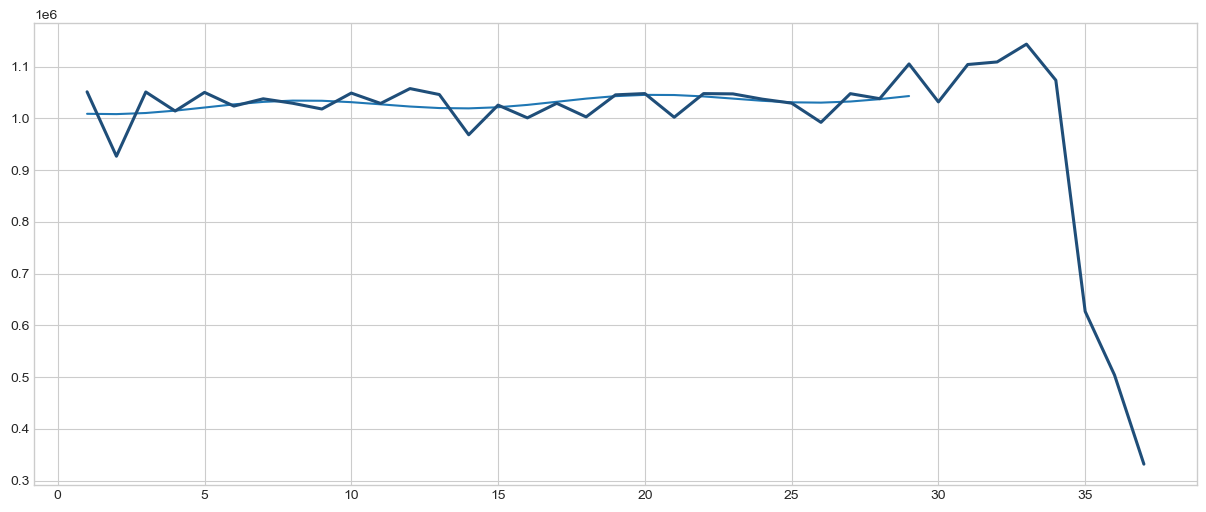

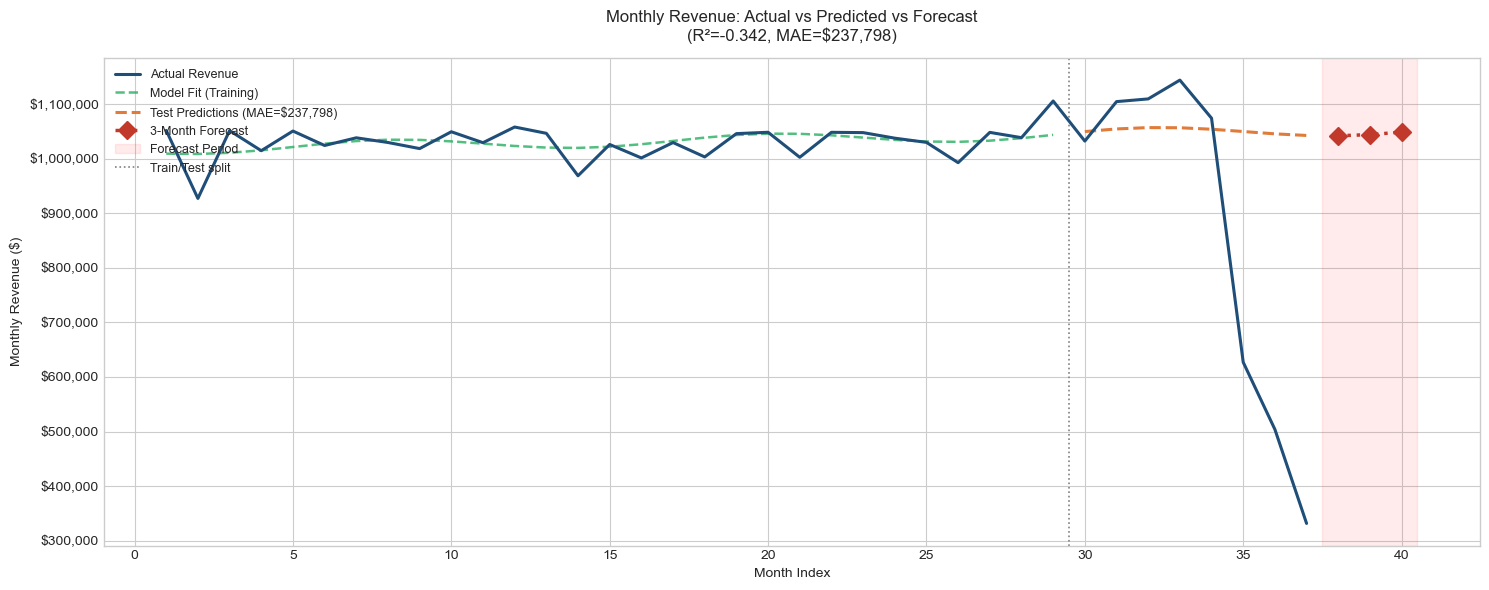

In [16]:
# CELL 6: Visualise forecast
# ============================================================
 
fig , ax = plt.subplots(figsize=(15, 6))
 
# All actual values
ax.plot(monthly['time_index'], monthly['monthly_revenue'],
        label='Actual Revenue', color='#1F4E79', linewidth=2.2, zorder=3)
 
# Model fit on training data
ax.plot(monthly['time_index'][:split_idx],
        model.predict(X_train)),
# CELL 6: Visualise forecast
# ============================================================
 
fig, ax = plt.subplots(figsize=(15, 6))
 
# All actual values
ax.plot(monthly['time_index'], monthly['monthly_revenue'],
        label='Actual Revenue', color='#1F4E79', linewidth=2.2, zorder=3)
 
# Model fit on training data
ax.plot(monthly['time_index'][:split_idx],
        model.predict(X_train),
        label='Model Fit (Training)', color='#27AE60',
        linestyle='--', linewidth=1.8, alpha=0.8)
 
# Predictions on test data
ax.plot(monthly['time_index'][split_idx:], y_pred,
        label=f'Test Predictions (MAE=${mae:,.0f})',
        color='#E07B39', linestyle='--', linewidth=2.2)
 
# Future forecast
ax.plot(future_df['time_index'], future_df['forecast_revenue'],
        label='3-Month Forecast', color='#C0392B',
        linestyle=':', linewidth=2.5, marker='D', markersize=9, zorder=4)
 
# Shade forecast region
ax.axvspan(last_time_idx + 0.5, last_time_idx + 3.5,
           alpha=0.08, color='red', label='Forecast Period')
 
# Vertical line separating train / test
ax.axvline(x=split_idx + 0.5, color='gray', linestyle=':',
           linewidth=1.2, label='Train/Test split')
 
ax.set_title(f'Monthly Revenue: Actual vs Predicted vs Forecast\n(R²={r2:.3f}, MAE=${mae:,.0f})',
             pad=12)
ax.set_xlabel('Month Index')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()



This chart compares actual revenue with model predictions and forecasted values.

We observe that revenue remains stable for most of the period, and the model performs well in capturing this trend during training.

However, there is a sharp decline in revenue in the later period, which the model fails to predict. The forecast continues to assume a stable trend.

This indicates that the model is not robust to sudden changes or external shocks, as it relies heavily on historical patterns.

From a business perspective, this suggests that the drop may be due to external factors such as market conditions or operational issues.

To improve accuracy, we should incorporate additional features and consider more advanced time-series models.